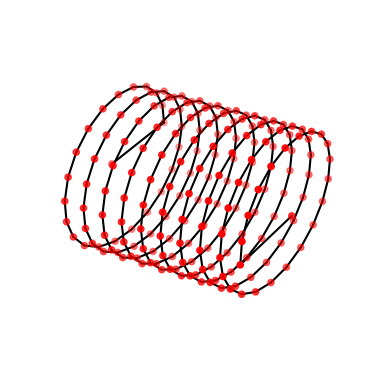

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=920,
                            youngs_rod=1e9,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

forces_to_apply = [np.array([500.0, 0.0, 0.0])]

# env.add_force('gravity', g=np.array([10, 0.0, 0.0]))
env.add_force('pointForces', point_force_node_indices=[geo.nodes.shape[0]-1], 
              point_force_vectors=forces_to_apply)
# env.add_force('damping', eta=100)

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0]) # fix the first node
robot = robot.fix_nodes(fixed_points)
end_force = []
def change_pointForces(robot, t):
    #slowly increase the point force over time
    factor = min(t/robot.sim_params.total_time, 1.0)
    robot.env.point_force_vectors = [factor * forces_to_apply[i] for i in range(len(forces_to_apply))]
    
    end_force.append(robot.env.point_force_vectors[0].copy())
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = change_pointForces

In [3]:
robots, t_arr, f_norms = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

end_force.append(forces_to_apply[0]) # add the final force at the end of the simulation

iter: 1, error: 0.000
current_time:  0.001
iter: 1, error: 0.500
iter: 2, error: 0.720
current_time:  0.002
iter: 1, error: 0.865
iter: 2, error: 3.719
current_time:  0.003
iter: 1, error: 1.393
iter: 2, error: 10.071
current_time:  0.004
iter: 1, error: 2.069
iter: 2, error: 20.381
current_time:  0.005
iter: 1, error: 2.854
iter: 2, error: 34.496
iter: 3, error: 0.131
current_time:  0.006
iter: 1, error: 3.725
iter: 2, error: 51.310
iter: 3, error: 0.263
current_time:  0.007
iter: 1, error: 4.628
iter: 2, error: 68.708
iter: 3, error: 0.428
current_time:  0.008
iter: 1, error: 5.521
iter: 2, error: 84.077
iter: 3, error: 0.572
current_time:  0.009000000000000001
iter: 1, error: 6.350
iter: 2, error: 95.881
iter: 3, error: 0.626
iter: 4, error: 0.148
current_time:  0.010000000000000002
iter: 1, error: 7.083
iter: 2, error: 104.168
iter: 3, error: 0.567
iter: 4, error: 0.158
current_time:  0.011000000000000003
iter: 1, error: 7.636
iter: 2, error: 107.474
iter: 3, error: 0.426
iter: 4, 

In [4]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

101


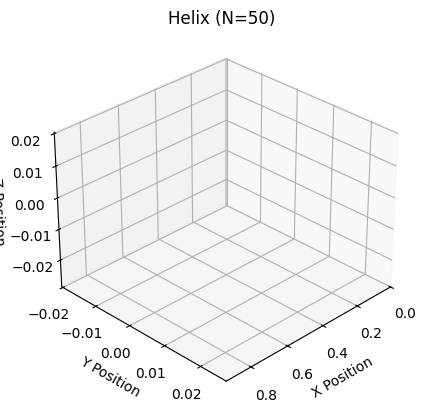

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

In [6]:
print(end_force)

[array([0., 0., 0.]), array([0.5, 0. , 0. ]), array([1., 0., 0.]), array([1.5, 0. , 0. ]), array([2., 0., 0.]), array([2.5, 0. , 0. ]), array([3., 0., 0.]), array([3.5, 0. , 0. ]), array([4., 0., 0.]), array([4.5, 0. , 0. ]), array([5., 0., 0.]), array([5.5, 0. , 0. ]), array([6., 0., 0.]), array([6.5, 0. , 0. ]), array([7., 0., 0.]), array([7.5, 0. , 0. ]), array([8., 0., 0.]), array([8.5, 0. , 0. ]), array([9., 0., 0.]), array([9.5, 0. , 0. ]), array([10.,  0.,  0.]), array([10.5,  0. ,  0. ]), array([11.,  0.,  0.]), array([11.5,  0. ,  0. ]), array([12.,  0.,  0.]), array([12.5,  0. ,  0. ]), array([13.,  0.,  0.]), array([13.5,  0. ,  0. ]), array([14.,  0.,  0.]), array([14.5,  0. ,  0. ]), array([15.,  0.,  0.]), array([15.5,  0. ,  0. ]), array([16.,  0.,  0.]), array([16.5,  0. ,  0. ]), array([17.,  0.,  0.]), array([17.5,  0. ,  0. ]), array([18.,  0.,  0.]), array([18.5,  0. ,  0. ]), array([19.,  0.,  0.]), array([19.5,  0. ,  0. ]), array([20.,  0.,  0.]), array([20.5,  0

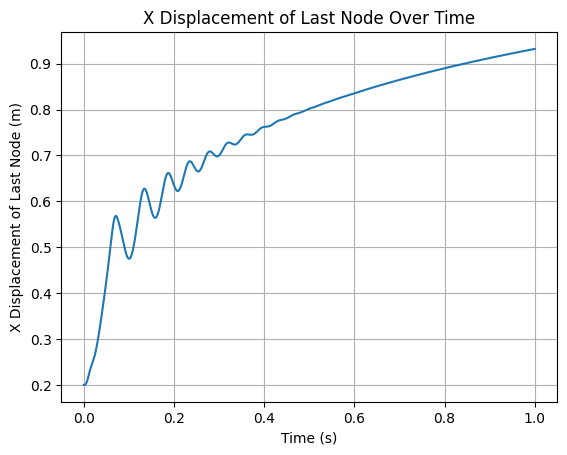

In [7]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

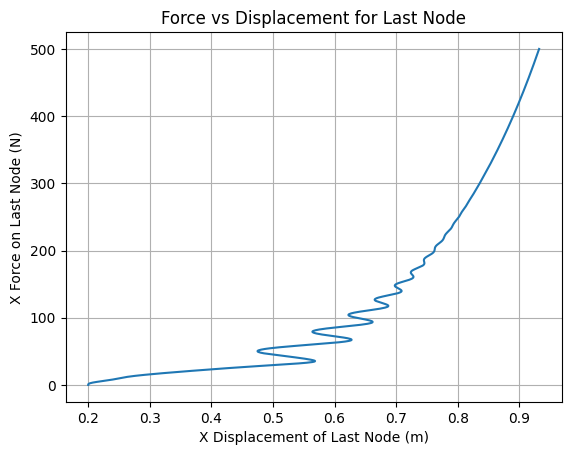

In [8]:
# plot force vs displacement for the last node
plt.figure()
plt.plot(last_node_x_disp, np.array(end_force)[:, 0]) # x component of the force
plt.xlabel('X Displacement of Last Node (m)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Force vs Displacement for Last Node')
plt.grid()
plt.show()

In [9]:
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]                  # (T, 3*n)
nodes = qs_nodes.reshape(T, robot.n_nodes, 3)         # (T, n, 3)

start_traj = nodes[:, 0, :].copy()                    # (T, 3)
end_traj   = nodes[:, -1, :].copy()                   # (T, 3)

start_traj[:, 1:] = 0.0
end_traj[:, 1:]   = 0.0

vs_nodes = vs[:, :robot.n_nodes * 3]
nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)     # (T, n, 3)

start_vel = nodes_vel[:, 0, :].copy()                 # (T, 3)
end_vel   = nodes_vel[:, -1, :].copy()                # (T, 3)

start_vel[:, 1:] = 0.0
end_vel[:, 1:]   = 0.0

centerline_nodes_traj = np.column_stack([
    start_traj,
    end_traj,
])                                                    # (T, 6)

centerline_node_vel = np.column_stack([
    start_vel,
    end_vel,
])                                                    # (T, 6)

xs_centerline = np.column_stack([
   centerline_nodes_traj,
    centerline_node_vel
])                                                    # (T, 12)

np.savez(
    "slinky_pulling_centerline_truth.npz",
    xs_centerline=xs_centerline,
    q_centerline=centerline_nodes_traj,
    v_centerline=centerline_node_vel,
)

In [10]:
# # get centroid trajectory (correct)
# T = qs.shape[0]

# qs_nodes = qs[:, :robot.n_nodes * 3]                    # (T, 3*n)
# nodes = qs_nodes.reshape(T, robot.n_nodes, 3)           # (T, n, 3)  where last dim is (x,y,z)
# start_traj = nodes[:, 0, :]                    # (T, 3)
# end_traj = nodes[:, -1, :]                      # (T, 3)
# end_traj[:, 1:] = 0.0                          # zero out y and z to get pure x trajectory

# vs_nodes = vs[:, :robot.n_nodes * 3]
# nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)       # (T, n, 3)
# start_vel = nodes_vel[:, 0, :]                   # (T, 3)
# end_vel = nodes_vel[:, -1, :]                   # (T, 3)
# end_vel[:, 1:] = 0.0                          # zero out y and z to get pure x velocity

# centerline_nodes_traj = np.hstack([start_traj, end_traj])  # (T, 6)

# centerline_edges_traj = np.zeros((T, 1))                # 2 nodes -> 2 edges

# centerline_node_vel = np.hstack([
#     start_vel,
#     end_vel,
# ])                                                      # (T, 6)

# centerline_angvel = np.zeros((T, 1))                    # 2 edges

# xs_centerline = np.hstack([
#     centerline_nodes_traj,
#     centerline_edges_traj,
#     centerline_node_vel,
#     centerline_angvel
# ])                                                      # (T, 6+1+6+1) = (T, 14)


In [11]:

print("centerline state shape:", xs_centerline.shape)
print("centerline_nodes_traj[0], centerline_nodes_traj[-1]:", centerline_nodes_traj[0], centerline_nodes_traj[-1])

np.savez("slinky_pulling_centerline_truth.npz", xs_centerline=xs_centerline)

centerline state shape: (1001, 12)
centerline_nodes_traj[0], centerline_nodes_traj[-1]: [0.  0.  0.  0.2 0.  0. ] [0.         0.         0.         0.93202787 0.         0.        ]
